#ANN ON CPU USING SAMPLE SUBSET OF FASHION MNSIT DATASET
---
AS WE WORKING ON CPU,HUGE DATASET WILL CAUSE TIME INEFFICIENCY AND HUGE LOAD SO WORKING WITH ONLY 6000 OUT OF 70 000 IMAGES WITH 4 NN LAYERS [784 FEATURES, 128 NERONS (RELU), 64 NEURONS (RELU), 10 NEURON OUTPUT (SOFTMAX)]

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [2]:
# Set random seeds for reproducibility
torch.manual_seed(42)

In [7]:
df = pd.read_csv('fmnist_small.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


/tmp/ipython-input-283096530.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  label = row[0]


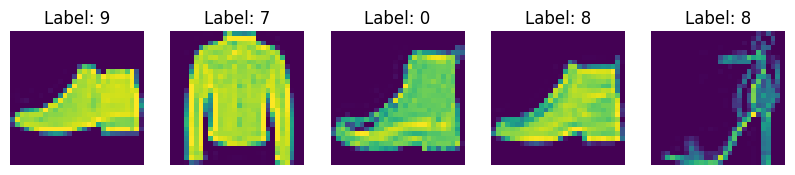

In [12]:
#random data vizulaize how the data looks like
import random
fig, axes = plt.subplots(1, 5, figsize=(10, 3))

for i in range(5):
    idx = random.randint(0, len(df)-1)
    row = df.iloc[idx]
    
    label = row[0]
    image = row[1:].values.reshape(28, 28)
    
    axes[i].imshow(image)
    axes[i].axis("off")
    axes[i].set_title(f"Label: {df.iloc[i, 0]}")

plt.show()

In [ ]:
#train test split
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# scaling the feautures values between 0 and 1 
X_train = X_train/255.0
X_test = X_test/255.0

X_train.shape, y_train.shape, X_test.shape, y_test.shape
X_train

array([[0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       ...,
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.0627451, 0.       ,
        0.       ]])

In [20]:
# create CustomDataset Class
class CustomDataset(Dataset):
    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

In [24]:
#train and test dataset
train_dataset = CustomDataset(X_train, y_train)
test_dataset = CustomDataset(X_test, y_test)

print(len(train_dataset), len(test_dataset))

4800 1200


In [23]:
#train and test dataloader
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(len(train_dataloader), len(test_dataloader))

150 38


In [26]:
#Cretae sequential NN class
class ANNnn(nn.Module):

    def __init__(self, num_features):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(num_features, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.model(x)

In [27]:
epochs = 100
learning_rate = 0.001

# instatiate the model
model = ANNnn(X_train.shape[1])
# loss function
lossfxn = nn.CrossEntropyLoss()
# optimizer
optimizer = optim.SGD(model.parameters(), lr= learning_rate)

In [28]:
#training loop
# training loop

for epoch in range(epochs): 
    total_epoch_loss = 0
    for batch_features, batch_labels in train_dataloader:
        # forward pass
        outputs = model(batch_features)
        # calculate loss
        loss = lossfxn(outputs, batch_labels)
        # back pass
        optimizer.zero_grad()
        loss.backward()
        # update grads
        optimizer.step()
        total_epoch_loss = total_epoch_loss + loss.item()
    avg_loss = total_epoch_loss/len(train_dataloader)
    print(f'Epoch: {epoch + 1} , Loss: {avg_loss}')

Epoch: 1 , Loss: 2.302720020612081
Epoch: 2 , Loss: 2.2887503814697268
Epoch: 3 , Loss: 2.275142863591512
Epoch: 4 , Loss: 2.2618054008483885
Epoch: 5 , Loss: 2.247667498588562
Epoch: 6 , Loss: 2.2320830138524372
Epoch: 7 , Loss: 2.214513961474101
Epoch: 8 , Loss: 2.1946947050094603
Epoch: 9 , Loss: 2.172573601404826
Epoch: 10 , Loss: 2.148053771654765
Epoch: 11 , Loss: 2.1207188749313355
Epoch: 12 , Loss: 2.090205351511637
Epoch: 13 , Loss: 2.0561222378412882
Epoch: 14 , Loss: 2.018382910092672
Epoch: 15 , Loss: 1.9769838086764018
Epoch: 16 , Loss: 1.9320324818293253
Epoch: 17 , Loss: 1.883853136698405
Epoch: 18 , Loss: 1.8332163580258687
Epoch: 19 , Loss: 1.7809747687975566
Epoch: 20 , Loss: 1.7281179467837016
Epoch: 21 , Loss: 1.67558189868927
Epoch: 22 , Loss: 1.6242455792427064
Epoch: 23 , Loss: 1.5747018885612487
Epoch: 24 , Loss: 1.5275002924601238
Epoch: 25 , Loss: 1.4826633127530415
Epoch: 26 , Loss: 1.4404531780878702
Epoch: 27 , Loss: 1.4008608675003051
Epoch: 28 , Loss: 1.3

In [29]:
#evaluation
model.eval()

ANNnn(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [31]:
#evaluation loop without libraries
with torch.inference_mode():
    test_loss, correct, total = 0, 0, 0
    for batch_features, batch_labels in test_dataloader:
        outputs = model(batch_features)
        loss = lossfxn(outputs, batch_labels)
        test_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += batch_labels.size(0)
        correct += (predicted == batch_labels).sum().item()
print(f'Test Loss: {test_loss/len(test_dataloader):.4f}, Test Accuracy: {correct/total:.4f}')

Test Loss: 0.7071, Test Accuracy: 0.7500
